In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[11,11,1], grid=5, k=3, seed=0,device=device)

checkpoint directory created: ./model
saving model version 0.0


In [2]:
import pandas as pd

# Load your dataset
df = pd.read_csv('customer_data_drop_na.csv')
# Select features and target variable

features = df[['fea_1','fea_2',	'fea_3','fea_4','fea_5','fea_6','fea_7','fea_8','fea_9','fea_10','fea_11']]
features = features.fillna(features.mean()).values # replace the null value with the mean
target = df['label']

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}

# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([976, 11]), torch.Size([976]))

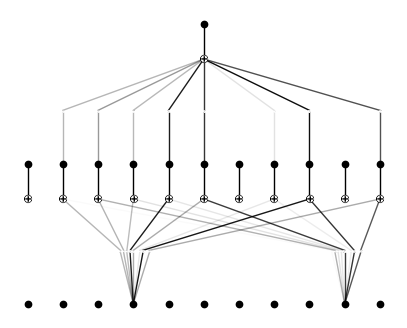

In [3]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot()

| train_loss: 2.23e+00 | test_loss: 2.23e+00 | reg: 3.00e+01 | : 100%|█| 100/100 [01:14<00:00,  1.34


saving model version 0.1


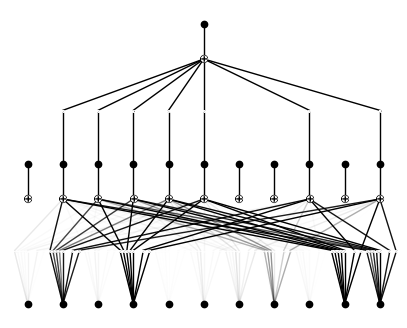

In [4]:
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)

saving model version 0.2


| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 1.44e+01 | : 100%|█| 100/100 [00:31<00:00,  3.15

saving model version 0.3


{'train_loss': [array(2.221746, dtype=float32),
  array(2.1932707, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.1888688, dtype=float32),
  array(2.188869, dtype=float32),
  array(2.1888688, dtype=float32),
  array(

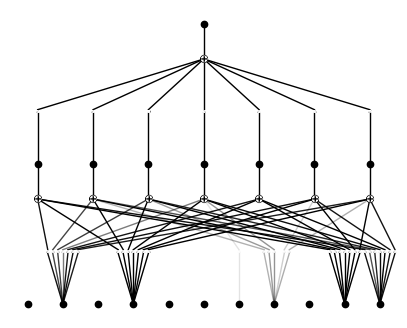

In [5]:
model = model.prune()
model.plot()
# train again after pruning
model.fit(dataset, opt="LBFGS", steps=100)

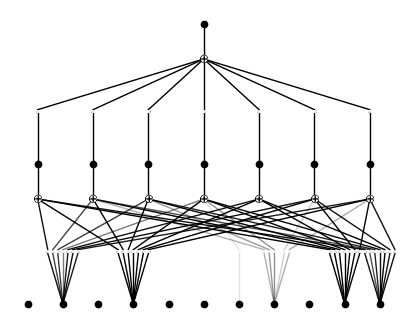

In [6]:
model.plot()

| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 4.89e+01 | : 100%|█| 50/50 [00:19<00:00,  2.51it


saving model version 0.4
saving model version 0.5


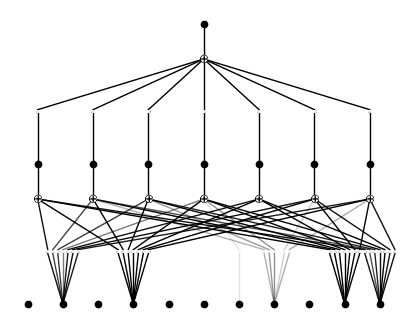

In [7]:
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(5)
model.plot()

| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 4.89e+01 | : 100%|█| 50/50 [00:28<00:00,  1.76it


saving model version 0.6
saving model version 0.7


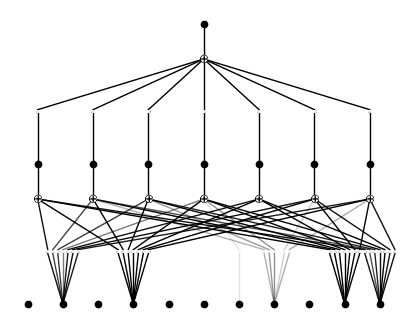

In [8]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(10)
model.plot()

| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 4.89e+01 | : 100%|█| 50/50 [00:19<00:00,  2.53it


saving model version 0.8
saving model version 0.9


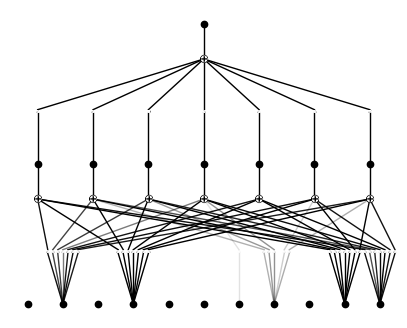

In [9]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(25)
model.plot()

| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 4.89e+01 | : 100%|█| 50/50 [00:24<00:00,  2.03it


saving model version 0.10


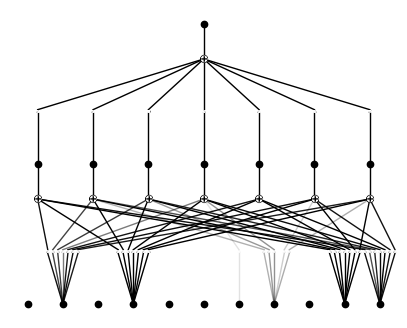

In [10]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 4.89e+01 | : 100%|█| 50/50 [00:23<00:00,  2.10it


saving model version 0.11


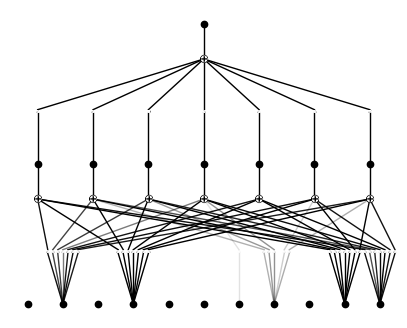

In [11]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

In [12]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
nsimplify(formula)

fixing (0,0,0) with 0
fixing (0,0,1) with 0
fixing (0,0,2) with 0
fixing (0,0,3) with 0
fixing (0,0,4) with 0
fixing (0,0,5) with 0
fixing (0,0,6) with 0
fixing (0,1,0) with x, r2=1.0000004768371582, c=1
fixing (0,1,1) with x, r2=1.0000003576278687, c=1
fixing (0,1,2) with x, r2=1.0000003576278687, c=1
fixing (0,1,3) with x, r2=1.0000003576278687, c=1
fixing (0,1,4) with x, r2=1.0000003576278687, c=1
fixing (0,1,5) with x, r2=1.0000003576278687, c=1
fixing (0,1,6) with x, r2=1.0000003576278687, c=1
fixing (0,2,0) with 0
fixing (0,2,1) with 0
fixing (0,2,2) with 0
fixing (0,2,3) with 0
fixing (0,2,4) with 0
fixing (0,2,5) with 0
fixing (0,2,6) with 0
fixing (0,3,0) with x, r2=1.0000003576278687, c=1
fixing (0,3,1) with x, r2=1.000000238418579, c=1
fixing (0,3,2) with x, r2=1.0000004768371582, c=1
fixing (0,3,3) with x, r2=1.0000003576278687, c=1
fixing (0,3,4) with x, r2=1.0000003576278687, c=1
fixing (0,3,5) with x, r2=1.0000004768371582, c=1
fixing (0,3,6) with x, r2=1.000000357627868

3355591341623*x_10/312500000000000 + 336668373369559*x_11/10000000000000000 + 14193241920339*x_2/1000000000000000 - 100439570596881*x_4/5000000000000000 + 54621770935541*x_8/2000000000000000 + 92086486940139*sin(181279823184013*x_7/1000000000000000 - 471760034561157/500000000000000)/500000000000000 + 380594461923109/500000000000

In [13]:
ex_round(formula, 4)

0.0107*x_10 + 0.0337*x_11 + 0.0142*x_2 - 0.0201*x_4 + 0.0273*x_8 + 0.1842*sin(0.1813*x_7 - 0.9435) + 761.1889